# **Customer Segmentation**

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Data Prepeocessing

In [2]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.shape

(200, 5)

In [4]:
df.describe().round()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0,200.0
mean,100.0,39.0,61.0,50.0
std,58.0,14.0,26.0,26.0
min,1.0,18.0,15.0,1.0
25%,51.0,29.0,42.0,35.0
50%,100.0,36.0,62.0,50.0
75%,150.0,49.0,78.0,73.0
max,200.0,70.0,137.0,99.0


### Exploratory Data Analysis

In [5]:
# Gender Distribution
df["Gender"].value_counts()

,count
Gender,
Female,112
Male,88


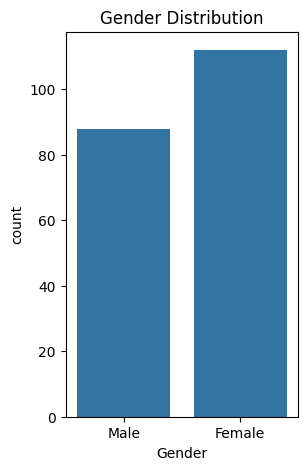

In [70]:
plt.figure(figsize=(3,5))
sns.countplot(x = "Gender" , data=df)
plt.title("Gender Distribution")
plt.show()

This graph shows the balance between male and female customers. According to the data, there are 112 female customers and 88 male customers, showing that the mall has a higher female shopper base.

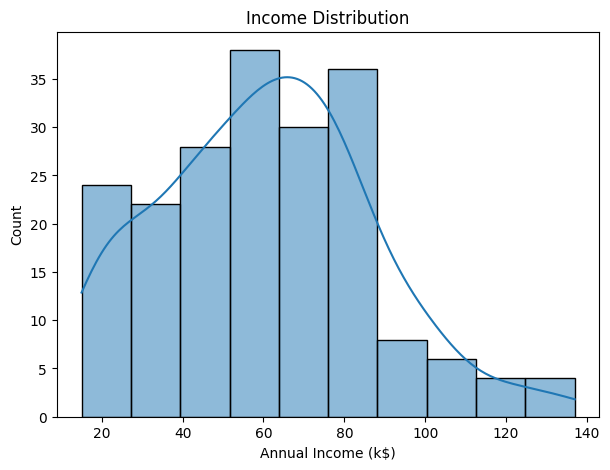

In [65]:
# Annual Income Distribution
plt.figure(figsize=(7,5))
sns.histplot(x = "Annual Income (k$)" , data=df , kde=True)
plt.title('Income Distribution')
plt.show()


This histogram with a density curve shows the spread of customers' annual income. Most shoppers earn between $40k  and  $80k per year, indicating that the majority of the mall's audience belongs to the middle-income group.

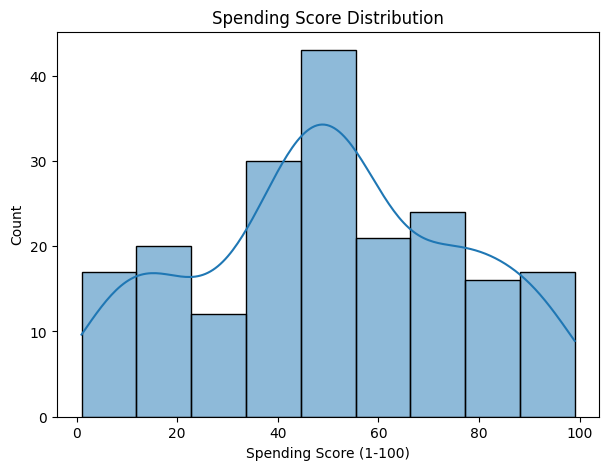

In [64]:
# Spnding Score Distribution
plt.figure(figsize=(7,5))
sns.histplot(x = "Spending Score (1-100)" , data=df , kde=True)
plt.title('Spending Score Distribution')
plt.show()


This plot analyzes the spending behavior of customers. We can see a significant density of customers with a spending score of 50, which suggests that a large portion of the shoppers has moderate spending habits.

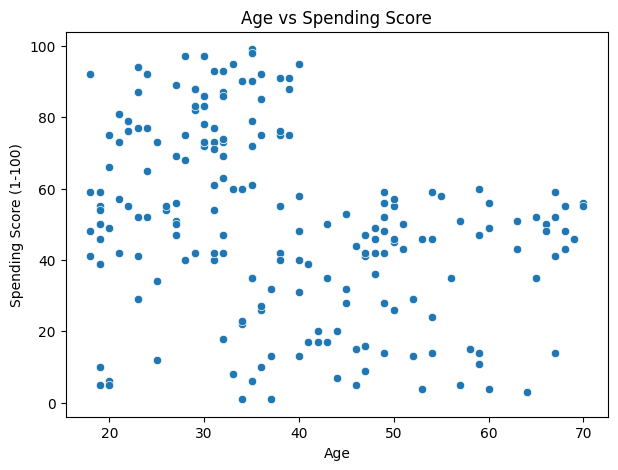

In [32]:
#5: Age vs Spending score
plt.figure(figsize=(7,5))
sns.scatterplot(x= "Age" , y="Spending Score (1-100)" , data=df)
plt.title('Age vs Spending Score')
plt.show()

This scatter plot explores the relationship between a customer's age and their spending score. It reveals that younger customers (under 40) are more likely to have higher spending scores, whereas older customers generally fall into a more moderate spending range.

--- Average Spending Score by Age Group ---
Age_group
18-35    60.797872
36-50    41.709677
51+      37.475000
Name: Spending Score (1-100), dtype: float64


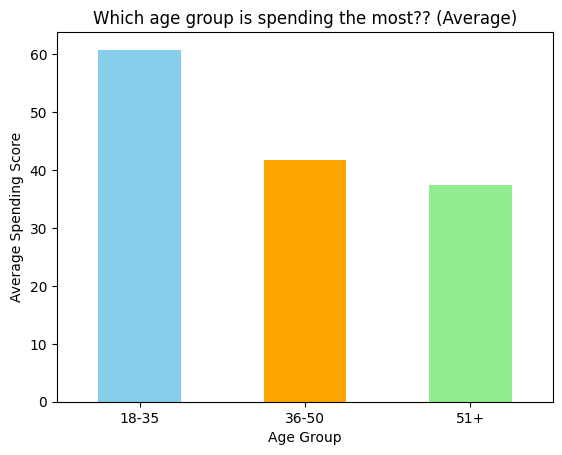

In [46]:
# Highest spending age group
df["Age_group"] = pd.cut(df["Age"], bins=[18, 35, 50, 70], labels=["18-35", "36-50", "51+"])
spending_analysis = df.groupby("Age_group", observed=False)["Spending Score (1-100)"].mean().sort_values(ascending=False)
print("--- Average Spending Score by Age Group ---")
print(spending_analysis)

spending_analysis.plot(kind='bar', color=['skyblue', 'orange', 'lightgreen'])
plt.title("Which age group is spending the most?? (Average)")
plt.xlabel("Age Group")
plt.ylabel("Average Spending Score")
plt.xticks(rotation=0)
plt.show()

----Gender based average spending score
Gender
Male      48.51
Female    51.53
Name: Spending Score (1-100), dtype: float64

Difference (Female - Male): 3.02


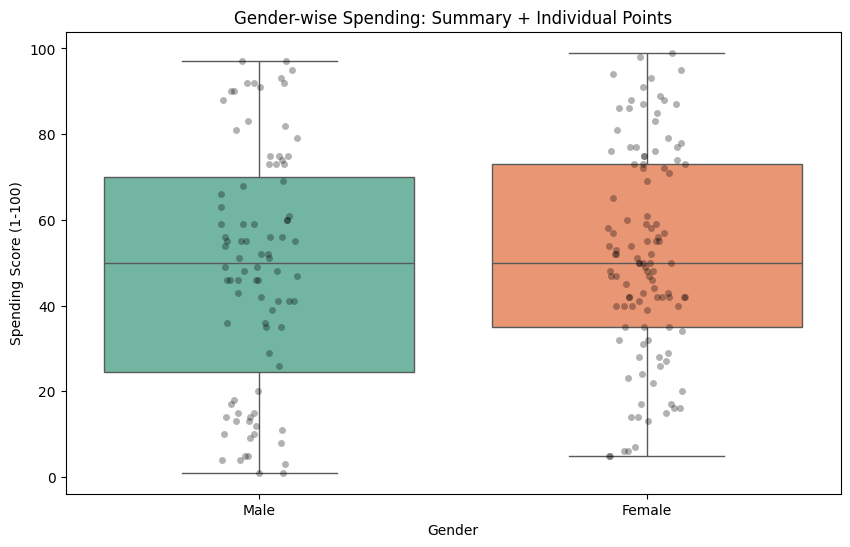

In [58]:
# Gender Spending Patterns

gender_analysis = df.groupby("Gender")["Spending Score (1-100)"].mean().sort_values().round(2)
print("----Gender based average spending score")
print(gender_analysis)

# diff between male and female
diff = (gender_analysis['Female'] - gender_analysis['Male']).round(2)
print(f"\nDifference (Female - Male): {diff}")

#visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Set2', hue='Gender', legend=False, whis=1.5)
sns.stripplot(x='Gender', y='Spending Score (1-100)', data=df, color='black', alpha=0.3)
plt.title('Gender-wise Spending: Summary + Individual Points')
plt.show()

There is a slight variance of 3.02 points between the two genders. While Females show a marginally higher engagement, the overall spending behavior remains relatively balanced across the customer base.
The box plot demonstrates that males show more volatility, with a larger segment of the group falling into the low-spending category, which ultimately reduces their group average.

### KMeans Clustring

In [19]:
#Transform values
scaler = StandardScaler()
X = df[["Annual Income (k$)","Spending Score (1-100)"]]
X_scaled = scaler.fit_transform(X)

## Determining the Optimal Number of Clusters (Elbow Method)

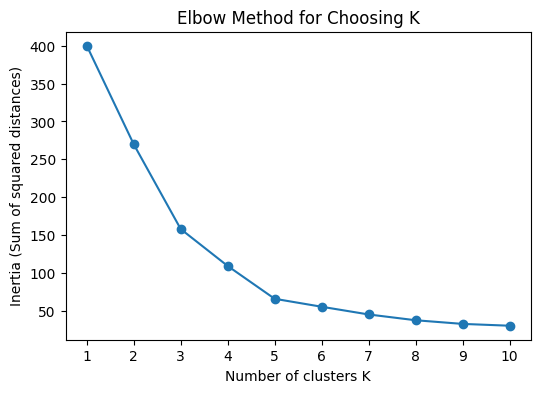

In [59]:
# Elbow Method: compute inertia (sum of squared distances) for different K
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k,random_state=42 , n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertia, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method for Choosing K')
plt.xticks(list(K_range))
plt.show()

The Elbow Method suggested that 5 is the optimal number of clusters as the inertia drop becomes gradual after this point

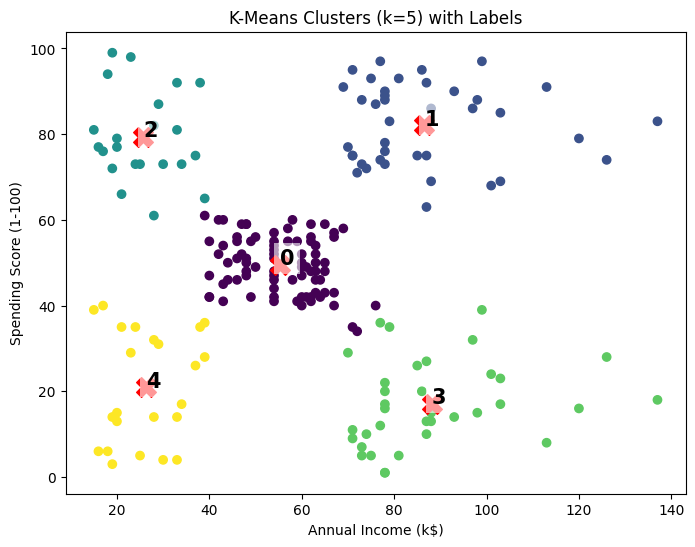

In [61]:
# Apply K-Means with K=5
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

#scatter the clusters
plt.figure(figsize=(8, 6))
plt.scatter(df["Annual Income (k$)"], df['Spending Score (1-100)'], c=clusters, cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clusters (k=5) with Labels')

# Reverse the scaling to get the original values
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200, color='red')

for i, point in enumerate(centroids):
    plt.text(point[0], point[1], str(i), fontsize=15, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.show()

Visual inspection of the Scatter Plot confirms that there is no significant overlap between the five identified customer segments.

## Model Evaluation: Silhouette Analysis

In [63]:
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.2f}")

Silhouette Score: 0.55


The model achieved a Silhouette Score of 0.55.
This score indicates that the clusters are well defined and the data points are significantly closer to their assigned cluster centers than to neighboring clusters.This value suggests that there is very little overlap between the groups, in other words we can say that the high spenders are clearly distinct from the low-spenders.

## Insights


**Cluster 0 (Standard Customers):** This segment represents customers with average annual income and average spending scores. They are the most consistent and predictable group for the mall.

**Cluster 1 (Target/Premium Group):** These are high-income individuals who also have high spending scores. They are the most profitable segment and should be the primary focus for luxury marketing and exclusive rewards.

**Cluster 2 (Impulsive Spenders):** This group has low annual income but maintains high spending scores. This segment often consists of younger customers who prioritize lifestyle trends despite budget constraints.

**Cluster 3 (Conservative Spenders):** These customers have high annual income but very low spending scores. They represent a significant opportunity for the mall to increase revenue through targeted high-value promotions.

**Cluster 4 (Sensible Spenders):** This segment includes customers with low annual income and low spending scores. They are price-sensitive and likely only purchase essential items or shop during major sales.



### Model Predictions

In [28]:
# Predictions
test_data = [[50, 40], [80, 80], [20, 90], [20, 20], [50, 60]]
new_data_scaled = scaler.transform(test_data)
predictions = kmeans.predict(new_data_scaled)

cluster_names = {
    0: "Standard Customers",
    1: "Target/Premium Group",
    2: "Impulsive Spenders",
    3: "Conservative Spenders",
    4: "Sensible Spenders"
}

for i in range(len(test_data)):
    cluster_num = predictions[i]
    cluster_name = cluster_names[cluster_num]
    print(f"Customer {i+1} (Data: {test_data[i]}) belongs to: {cluster_name}")

Customer 1 (Data: [50, 40]) belongs to: Standard Customers
Customer 2 (Data: [80, 80]) belongs to: Target/Premium Group
Customer 3 (Data: [20, 90]) belongs to: Impulsive Spenders
Customer 4 (Data: [20, 20]) belongs to: Sensible Spenders
Customer 5 (Data: [50, 60]) belongs to: Standard Customers


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Identify the Whale Outliers

--- Identified 12 Premium VIP Customers ---
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
7            8  Female   23                  18                      94   
11          12  Female   35                  19                      99   
19          20  Female   35                  23                      98   
33          34    Male   18                  33                      92   
41          42    Male   24                  38                      92   

   Age_group  Cluster       Customer_Tag  
7      18-35        2  Whale/Premium VIP  
11     18-35        2  Whale/Premium VIP  
19     18-35        2  Whale/Premium VIP  
33       NaN        2  Whale/Premium VIP  
41     18-35        2  Whale/Premium VIP  


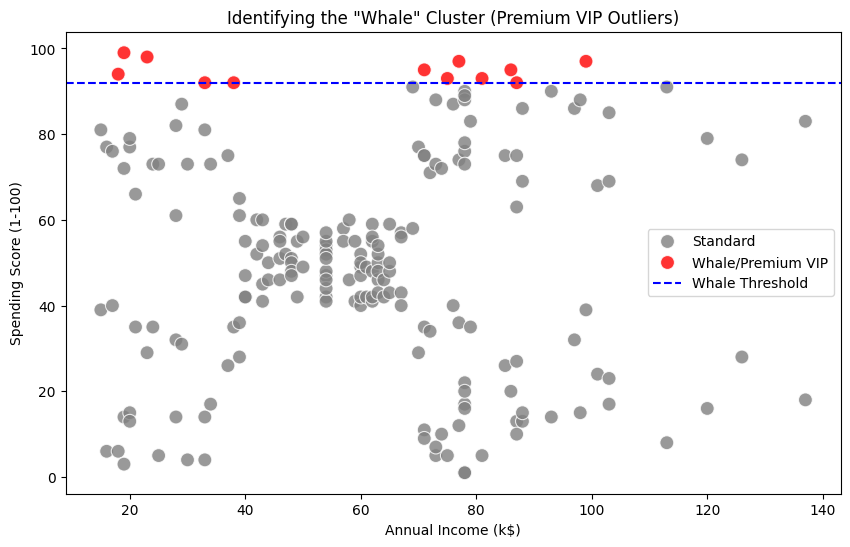

In [77]:
# Identify the Whales using a percentile threshold
spending_threshold = df['Spending Score (1-100)'].quantile(0.95)

df['Customer_Tag'] = 'Standard'

df.loc[df['Spending Score (1-100)'] >= spending_threshold, 'Customer_Tag'] = 'Whale/Premium VIP'
premium_segment = df[df['Customer_Tag'] == 'Whale/Premium VIP']

print(f"--- Identified {len(premium_segment)} Premium VIP Customers ---")
print(premium_segment.head())

# Visualize the Whales in a different color
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Customer_Tag', palette={'Standard': 'grey', 'Whale/Premium VIP': 'red'},
                s=100, alpha=0.8)

plt.title('Identifying the "Whale" Cluster (Premium VIP Outliers)')
plt.axhline(y=spending_threshold, color='blue', linestyle='--', label='Whale Threshold')
plt.legend()
plt.show()

Instead of deleting unusual data, we have identified a Whale Cluster, the top 5% of our highest spenders. **The blue dashed line** shows our cutoff point (Score $\approx$ 92). Anyone above this line is a Premium VIP. **These high value red dots** are the outliers. Even though they are few, they are our most valuable customers because their spending is at the maximum level, regardless of their income.So, We don't treat these as errors in the data. Instead, we label them as a special segment for exclusive loyalty programs and high-end offers.